## Overview

This project develops and evaluates machine learning models for predicting the presence of heart disease using routinely collected clinical data. Multiple classification algorithms are compared to identify the model that provides the best predictive performance while maintaining clinical interpretability.

##  Project Objective

The objective of this project is to investigate whether routinely collected clinical variables can be used to predict the presence of heart disease using machine learning techniques.

The project aims to:

- Understand the clinical problem of coronary artery disease.
- Explore and assess the quality of the dataset.
- Perform exploratory data analysis (EDA).
- Build and compare multiple machine learning models.
- Interpret the results from both a machine learning and clinical perspective.


### Research Questions

1. Can machine learning accurately predict the presence of heart disease?

2. Which machine learning model performs best on this dataset?

3. Which clinical variables contribute most to the prediction?

4. Can interpretable machine learning support clinical decision making?

## Clinical Background

Coronary artery disease (CAD) is one of the leading causes of death worldwide. Early identification of patients at risk is essential for improving clinical outcomes and reducing healthcare costs.

Machine learning has the potential to assist clinicians by identifying patterns in routinely collected clinical data that may indicate the presence of heart disease.
This project investigates whether machine learning models can assist in the early identification of patients at risk of heart disease using routinely available clinical information.

## Dataset Description

The dataset contains anonymized clinical information collected from patients undergoing cardiovascular assessment.

Each row represents one patient.

Each column represents one clinical variable.

The target variable indicates whether heart disease is present or absent.

Target Variable

- 0 = No Heart Disease
- 1 = Heart Disease

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
# Define the column names
column_names = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

## Loading the Dataset

The dataset is loaded into a Pandas DataFrame to enable exploration, preprocessing, visualization, and model development.

In [18]:
# Load the dataset
df = pd.read_csv(r"..\data\heart.csv", names=column_names, header=None)

In [19]:
# Display the first five rows of the dataset
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0


### Interpretation

The first five observations provide an initial overview of the dataset structure.

Each row corresponds to one patient, while each column represents a clinical measurement that may contribute to predicting heart disease.

Inspecting the first few records helps verify that the dataset has been loaded correctly.

In [20]:
df.shape

(303, 14)

### Interpretation

The dataset dimensions indicate the number of patient records and clinical variables available for analysis.

Understanding the dataset size is important because it influences the choice of machine learning algorithms and the reliability of model evaluation.

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    str    
 12  thal      303 non-null    str    
 13  target    303 non-null    int64  
dtypes: float64(1), int64(11), str(2)
memory usage: 33.3 KB


### Interpretation

The dataset information provides an overview of the data types, non-null values, and memory usage for each feature.

This step helps identify missing values and confirms whether the variables have appropriate data types before preprocessing.

In [22]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000


### Interpretation

The descriptive statistics summarize the distribution of the numerical variables, including measures such as the mean, standard deviation, minimum, maximum, and quartiles.

These statistics provide an initial understanding of the range and variability of the clinical measurements.

In [23]:
df["ca"].unique()

<StringArray>
['0', '3', '2', '1', '?']
Length: 5, dtype: str

In [24]:
# Count the number of '?' values in each column
(df == "?").sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [25]:
df[df["ca"] == "?"]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
166,52,1,3,138,223,0,0,169,0,0.0,1,?,3,0
192,43,1,4,132,247,1,2,143,1,0.1,2,?,7,1
287,58,1,2,125,220,0,0,144,0,0.4,2,?,7,0
302,38,1,3,138,175,0,0,173,0,0.0,1,?,3,0


In [26]:
df[df["thal"] == "?"]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
87,53,0,3,128,216,0,2,115,0,0.0,1,0,?,0
266,52,1,4,128,204,1,0,156,1,1.0,2,0,?,2


In [27]:
# Replace '?' with missing values (NaN)
df = df.replace("?", np.nan)

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    str    
 12  thal      301 non-null    str    
 13  target    303 non-null    int64  
dtypes: float64(1), int64(11), str(2)
memory usage: 33.3 KB


## Data Type Conversion

In [29]:
# Convert columns to numeric data types
df["ca"] = pd.to_numeric(df["ca"])
df["thal"] = pd.to_numeric(df["thal"])

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [31]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [32]:
(df.isnull().sum() / len(df)) * 100

age         0.000000
sex         0.000000
cp          0.000000
trestbps    0.000000
chol        0.000000
fbs         0.000000
restecg     0.000000
thalach     0.000000
exang       0.000000
oldpeak     0.000000
slope       0.000000
ca          1.320132
thal        0.660066
target      0.000000
dtype: float64

## Handling Missing Values

In [33]:
# Remove rows containing missing values
df = df.dropna()

In [34]:
df.shape

(297, 14)

# Exploratory Data Analysis (EDA)
Exploratory Data Analysis (EDA) is performed to understand the characteristics of the dataset before developing machine learning models. This includes examining the distribution of clinical variables, identifying potential relationships with the target variable, and detecting patterns that may influence model performance.

## Research Question 1

Who are the patients in this dataset?

In [35]:
# Summary statistics for numerical variables
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,3.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.676768,4.730640,0.946128
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,1.938629,1.234551
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


### Interpretation

The summary statistics provide an overview of the numerical clinical variables. Most patients are middle-aged to older adults, and considerable variation is observed in variables such as cholesterol, resting blood pressure, and maximum heart rate. Understanding these distributions helps identify potential outliers and guides subsequent preprocessing steps.

### Age Distribution

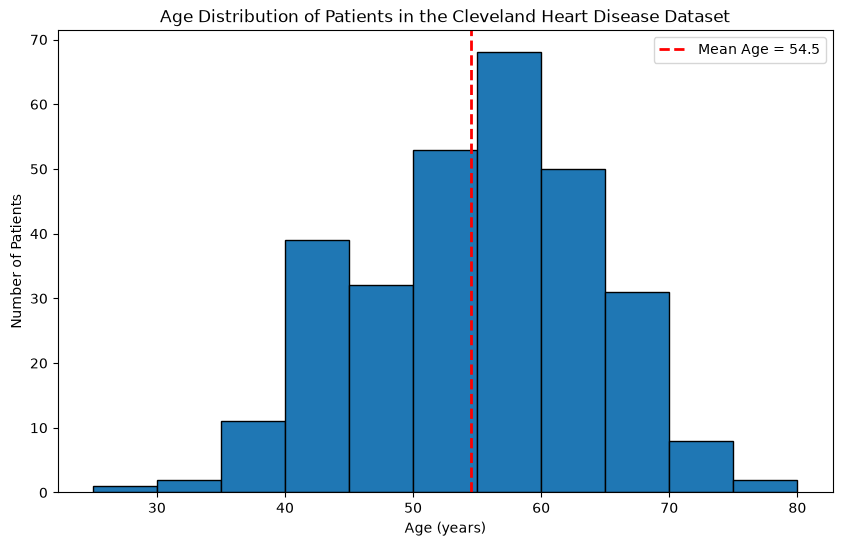

In [36]:
# Create the figure
plt.figure(figsize=(10,6))

# Plot histogram
plt.hist(
    df["age"],
    bins=range(25, 85, 5),
    edgecolor="black"
)

# Add average age
plt.axvline(
    df["age"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean Age = {df['age'].mean():.1f}"
)

# Titles
plt.title("Age Distribution of Patients in the Cleveland Heart Disease Dataset")

plt.xlabel("Age (years)")
plt.ylabel("Number of Patients")

plt.legend()

plt.show()

### Interpretation

The age distribution indicates that most patients in the dataset are between approximately 50 and 65 years of age. This is consistent with the increased prevalence of cardiovascular disease in older adults. The histogram also suggests that age is well distributed across the study population without obvious data quality issues.

### Sex Distribution

Understanding the sex distribution helps determine whether one group is overrepresented in the dataset, which may influence model performance and generalizability.

In [37]:
df["sex"].value_counts()

sex
1    201
0     96
Name: count, dtype: int64

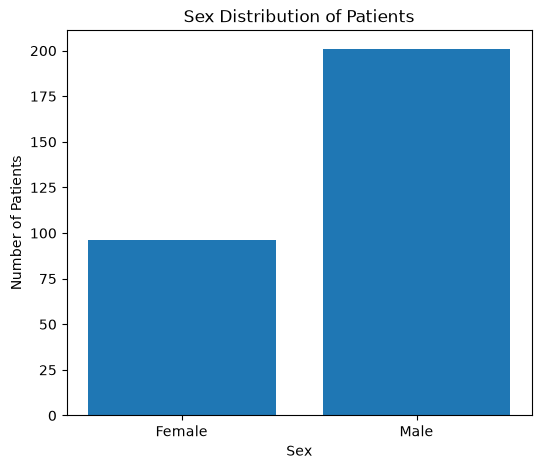

In [38]:
# Count males and females
sex_counts = df["sex"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(
    ["Female", "Male"],
    [sex_counts[0], sex_counts[1]]
)

plt.title("Sex Distribution of Patients")
plt.xlabel("Sex")
plt.ylabel("Number of Patients")

plt.show()

### Interpretation

The cleaned dataset contains 297 patients, of whom 201 (67.7%) are male and 96 (32.3%) are female. The predominance of male patients is consistent with the higher historical prevalence and diagnosis of coronary artery disease in men. It may also reflect the characteristics of the hospital population from which the dataset was collected. Therefore, the dataset should not be interpreted as representing the general population of Cleveland.The dataset is male-dominated, with males representing approximately two-thirds of the patients. This imbalance should be considered when interpreting the model's performance, as it may reflect the underlying population represented in the dataset.

### Target Variable Distribution

In [39]:
df["target"].value_counts().sort_index()

target
0    160
1     54
2     35
3     35
4     13
Name: count, dtype: int64

In [40]:
# Create a binary target variable
df["target_binary"] = (df["target"] > 0).astype(int)

In [41]:
df["target_binary"].value_counts()

target_binary
0    160
1    137
Name: count, dtype: int64

In [42]:
df.groupby("target_binary")["age"].mean()

target_binary
0    52.643750
1    56.759124
Name: age, dtype: float64

### Interpretation

Patients diagnosed with heart disease have a higher average age than patients without heart disease. This observation is clinically plausible, as advancing age is a well-established risk factor for cardiovascular disease. However, age alone is unlikely to explain disease status and should be interpreted alongside other clinical variables.

<Figure size 800x600 with 0 Axes>

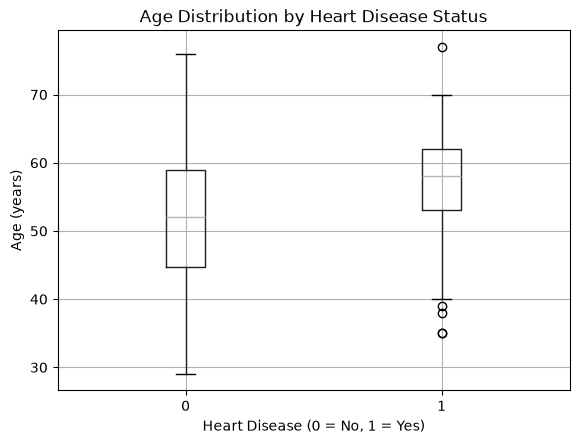

In [43]:
plt.figure(figsize=(8,6))

df.boxplot(column="age", by="target_binary")

plt.title("Age Distribution by Heart Disease Status")
plt.suptitle("")  # Removes the automatic title added by pandas
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Age (years)")

plt.show()

### Interpretation

The boxplot demonstrates that patients with heart disease generally tend to be older than those without heart disease. Although there is overlap between the two groups, the shift toward higher ages among affected patients suggests that age may contribute to disease prediction.

In [44]:
df.groupby("target_binary")["chol"].agg(["mean", "median", "std"])

,mean,median,std
target_binary,,,
0,243.493750,235.5,53.757550
1,251.854015,253.0,49.679937


<Figure size 800x600 with 0 Axes>

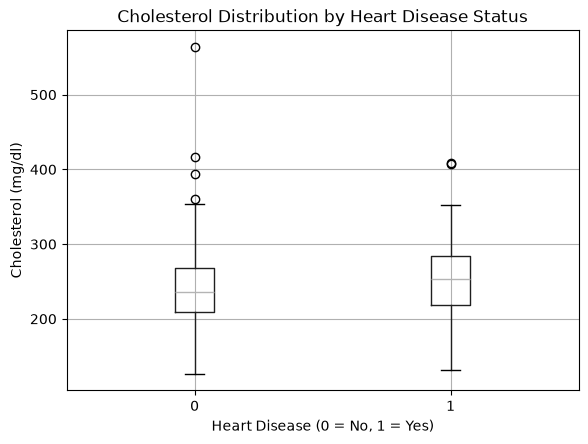

In [45]:
plt.figure(figsize=(8,6))

df.boxplot(column="chol", by="target_binary")

plt.title("Cholesterol Distribution by Heart Disease Status")
plt.suptitle("")  # Removes the automatic title added by pandas
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Cholesterol (mg/dl)")

plt.show()

### Interpretation

Patients with heart disease exhibit slightly higher cholesterol levels on average; however, substantial overlap exists between the two groups. This suggests that cholesterol alone may not be a strong predictor of heart disease and is likely to be more informative when combined with other clinical features.

In [46]:
df.groupby("target_binary")["trestbps"].agg(["mean", "median", "std"])

,mean,median,std
target_binary,,,
0,129.175000,130.0,16.37399
1,134.635036,130.0,18.89673


<Figure size 800x600 with 0 Axes>

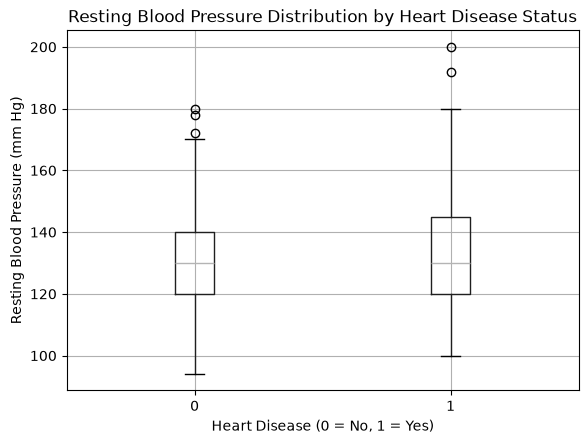

In [47]:
plt.figure(figsize=(8,6))

df.boxplot(column="trestbps", by="target_binary")

plt.title("Resting Blood Pressure Distribution by Heart Disease Status")
plt.suptitle("")  # Removes the automatic title added by pandas
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Resting Blood Pressure (mm Hg)")

plt.show()

### Interpretation

Resting blood pressure shows considerable overlap between patients with and without heart disease. While elevated blood pressure is a known cardiovascular risk factor, this dataset suggests that it does not clearly separate the two groups when considered independently.

In [48]:
df.groupby("target_binary")["thalach"].agg(["mean", "median", "std"])

,mean,median,std
target_binary,,,
0,158.581250,161.0,19.043304
1,139.109489,142.0,22.710673


<Figure size 800x600 with 0 Axes>

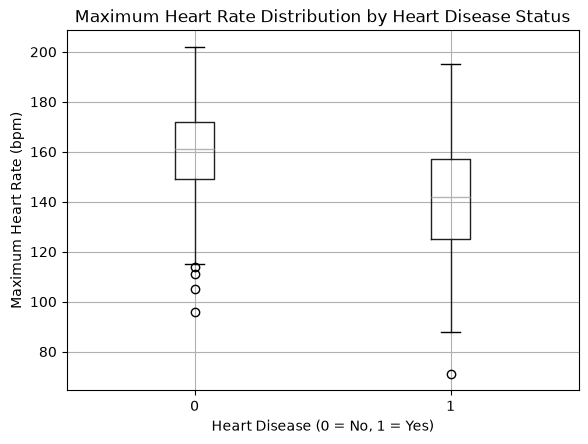

In [49]:
plt.figure(figsize=(8,6))

df.boxplot(column="thalach", by="target_binary")

plt.title("Maximum Heart Rate Distribution by Heart Disease Status")
plt.suptitle("")  # Removes the automatic title added by pandas
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Maximum Heart Rate (bpm)")

plt.show()

In [50]:
df.groupby("target_binary")["oldpeak"].agg(["mean", "median", "std"])

,mean,median,std
target_binary,,,
0,0.598750,0.2,0.787160
1,1.589051,1.4,1.305006


### Interpretation

Patients diagnosed with heart disease generally achieved lower maximum heart rates during exercise than patients without heart disease. This finding is clinically meaningful because reduced exercise capacity is commonly associated with cardiovascular dysfunction.

<Figure size 800x600 with 0 Axes>

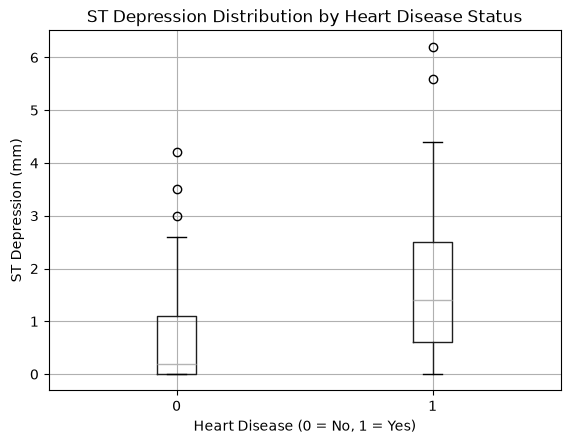

In [51]:
plt.figure(figsize=(8,6))

df.boxplot(column="oldpeak", by="target_binary")

plt.title("ST Depression Distribution by Heart Disease Status")
plt.suptitle("")  # Removes the automatic title added by pandas
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("ST Depression (mm)")


plt.show()

### Interpretation

Patients with heart disease exhibit noticeably higher ST depression (Oldpeak) values compared with patients without heart disease. The separation observed in the boxplot suggests that Oldpeak may be an important predictor of heart disease.

In [52]:
df.groupby("target_binary")["exang"].agg(["mean", "median", "std"])

,mean,median,std
target_binary,,,
0,0.143750,0.0,0.351938
1,0.540146,1.0,0.500215


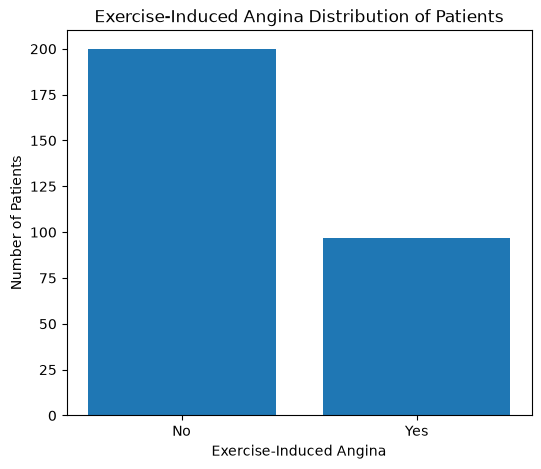

In [53]:
exang_counts = df["exang"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(
    ["No", "Yes"],
    [exang_counts[0], exang_counts[1]]
)

plt.title("Exercise-Induced Angina Distribution of Patients")
plt.xlabel("Exercise-Induced Angina")
plt.ylabel("Number of Patients")

plt.show()

### Interpretation

Exercise-induced angina appears more frequently among patients with heart disease than among healthy patients. This finding is clinically expected and suggests that this feature may contribute substantially to predictive model performance.

In [54]:
X = df.drop(columns=["target", "target_binary"])
y = df["target_binary"]

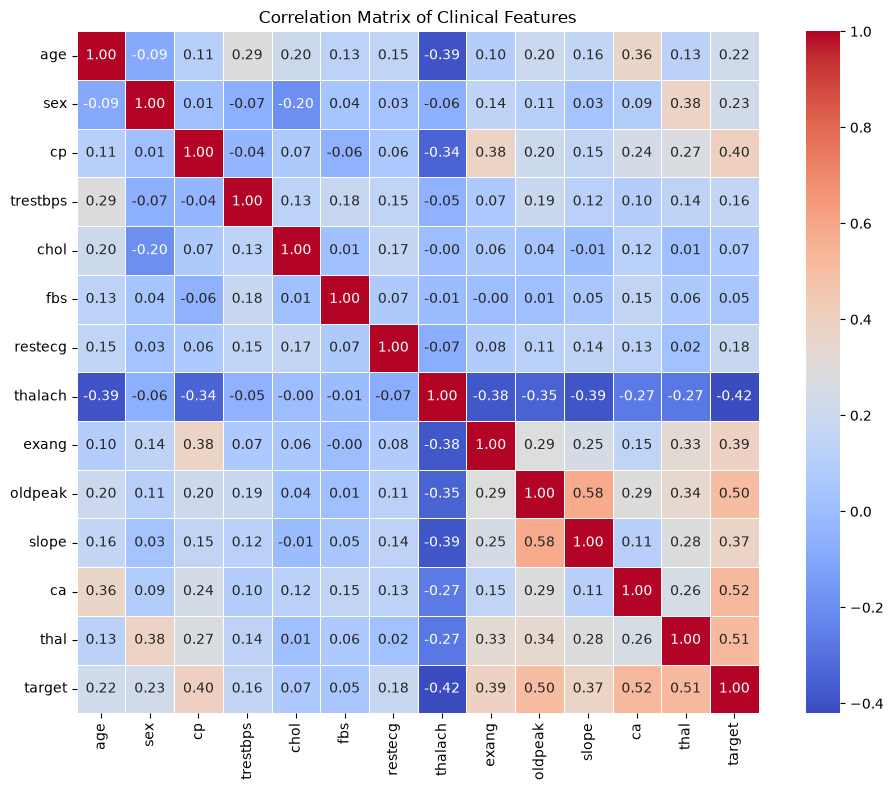

In [55]:
import seaborn as sns
corr = df.corr(numeric_only=True)
corr = df.drop(columns=["target_binary"]).corr(numeric_only=True)

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Matrix of Clinical Features")
plt.tight_layout()
plt.tight_layout()

plt.savefig(
    "../images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.show()

### Interpretation

The correlation heatmap provides an overview of the linear relationships between the clinical variables and the target variable.

Several features, including **ca**, **thal**, **oldpeak**, **chest pain type (cp)**, and **exercise-induced angina (exang)**, show moderate positive correlations with the presence of heart disease. Conversely, **maximum heart rate achieved (thalach)** exhibits a moderate negative correlation, indicating that patients with lower maximum heart rates are more likely to have heart disease.

Most feature-to-feature correlations are relatively weak to moderate, suggesting that severe multicollinearity is not present in the dataset. This is beneficial because it reduces redundancy among predictors and allows machine learning models to learn complementary information from multiple clinical variables.

## Summary of Exploratory Data Analysis

The exploratory analysis identified several clinically meaningful patterns within the dataset.

Key observations include:

- Patients with heart disease tend to be older.
- Patients with heart disease generally achieve lower maximum heart rates.
- Oldpeak shows clear separation between healthy and diseased patients.
- Cholesterol and resting blood pressure exhibit considerable overlap between groups.
- Exercise-induced angina appears more common among patients with heart disease.

These findings suggest that multiple clinical variables contribute to disease prediction and justify the use of machine learning models capable of combining information from several features simultaneously.

# Data Preparation for Machine Learning
Data preprocessing prepares the dataset for machine learning by ensuring that the input data is clean, consistently formatted, and suitable for model training. In this project, preprocessing includes checking for missing values, selecting features and the target variable, splitting the data into training and testing sets, and standardizing the continuous variabl

## Train-Test Split

The dataset is divided into independent training and testing sets to evaluate model performance on previously unseen data.

The training set is used to train the machine learning models, while the testing set is reserved for evaluating their ability to generalize to new patients.

An 80:20 split is used in this project.

In [56]:
from sklearn.model_selection import train_test_split

In [57]:
random_state = 42

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [59]:
X_train.shape
X_test.shape
y_train.shape
y_test.shape


(60,)

### Interpretation

The dataset has been successfully divided into training and testing sets. Separating the data before model training prevents information leakage and provides an unbiased evaluation of model performance.

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [61]:
X = df.drop(columns=["target", "target_binary"])
y = df["target_binary"]

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Identifying Continuous and Categorical Features

Continuous and categorical variables require different preprocessing strategies.

Continuous variables are standardized before model training, whereas categorical variables are retained in their original encoded form.

In [63]:
continuous_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

In [64]:
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

## Feature Scaling

Continuous variables are standardized using StandardScaler.

The scaler is fitted only on the training data and then applied to both the training and testing datasets. This prevents information from the testing data from influencing the training process.

In [65]:
scaler = StandardScaler()

In [66]:
scaler.fit(X_train[continuous_features])

StandardScaler()

In [67]:
X_train_scaled = scaler.transform(
    X_train[continuous_features]
)

X_test_scaled = scaler.transform(
    X_test[continuous_features]
)

### Interpretation

The continuous variables have been successfully standardized. Each feature now has a comparable scale, allowing algorithms such as Logistic Regression to train more effectively.

In [68]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=continuous_features,
    index=X_train.index
)

In [69]:
X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=continuous_features,
    index=X_test.index
)

## Combining Continuous and Categorical Variables

After scaling the continuous variables, they are combined with the categorical variables to create the final datasets used for machine learning.

In [70]:
X_train_categorical = X_train[categorical_features]

X_test_categorical = X_test[categorical_features]

In [71]:
X_train_processed = pd.concat(
    [X_train_scaled, X_train_categorical],
    axis=1
)

In [72]:
X_test_processed = pd.concat(
    [X_test_scaled, X_test_categorical],
    axis=1
)

In [73]:
X_train_processed.shape

X_test_processed.shape

(60, 13)

In [74]:
X_train_processed.head()

,age,trestbps,chol,thalach,oldpeak,sex,cp,fbs,restecg,exang,slope,ca,thal
277,-1.741679,0.319284,-0.544213,0.151798,-0.915041,0,3,0,0,0,2,0.0,3.0
262,0.601114,0.985981,-0.161771,0.971399,-0.121634,0,1,0,0,0,1,0.0,3.0
30,1.605169,0.430400,-0.180893,0.108661,0.671774,0,1,0,0,0,1,2.0,3.0
22,0.377991,-0.680763,0.679601,0.496893,0.671774,1,2,0,2,0,2,0.0,3.0
281,-0.849186,-0.125182,0.086816,1.316494,-0.915041,1,3,0,0,0,1,0.0,3.0


### Interpretation

The processed training dataset now contains standardized continuous variables alongside the original categorical variables.

This dataset represents the final input that will be used to train all machine learning models in this project.

# Summary of Data Preprocessing

The preprocessing stage successfully prepared the dataset for machine learning by:

- Splitting the data into independent training and testing sets.
- Separating continuous and categorical variables.
- Standardizing the continuous features.
- Combining all processed variables into the final training and testing datasets.

The processed datasets are now ready for training and evaluating multiple machine learning models.

# Logistic Regression

## Why Logistic Regression?

Logistic Regression was selected as the first baseline machine learning model because it is widely used for binary classification problems in healthcare. It is computationally efficient, interpretable, and provides probability estimates that can support clinical decision-making.

The model is trained using the processed training dataset and evaluated on the independent testing dataset.

In [75]:
from sklearn.linear_model import LogisticRegression

In [76]:
model = LogisticRegression(random_state=42)

## Model Training

The Logistic Regression model is trained using the processed training dataset. During training, the algorithm learns the relationship between the clinical variables and the presence of heart disease.

In [77]:
model.fit(
    X_train_processed,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

## Model Prediction

After training, the model predicts the heart disease status for patients in the testing dataset. These predictions are used to evaluate model performance.

In [78]:
y_pred = model.predict(X_test_processed)

In [79]:
y_pred = model.predict(X_test_processed)
y_pred[:5]

array([0, 0, 0, 1, 0])

In [80]:
y_prob = model.predict_proba(X_test_processed)
y_prob[:5]

array([[0.97659594, 0.02340406],
       [0.76185689, 0.23814311],
       [0.98215374, 0.01784626],
       [0.01119508, 0.98880492],
       [0.95255392, 0.04744608]])

## Confusion Matrix

The confusion matrix summarizes the classification results by comparing the predicted labels with the true labels.

It reports:

- True Positives
- True Negatives
- False Positives
- False Negatives

These values provide insight into the types of errors made by the model.

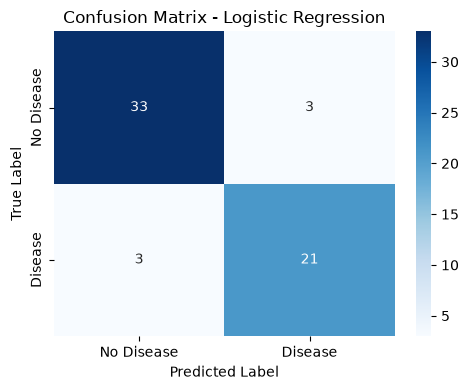

In [81]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease","Disease"],
    yticklabels=["No Disease","Disease"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression")

plt.tight_layout()
plt.tight_layout()

plt.savefig(
    "../images/logistic_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.show()

### Interpretation

The confusion matrix indicates that the Logistic Regression model correctly classified the majority of patients. Only a small number of healthy patients were incorrectly classified as having heart disease (false positives), and only a few patients with heart disease were missed (false negatives). These results demonstrate strong overall predictive performance.

## Model Evaluation

The model is evaluated using four commonly used classification metrics:

- Accuracy
- Precision
- Recall
- F1-score

Together, these metrics provide a comprehensive assessment of model performance.

In [82]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))

Accuracy : 0.9
Precision: 0.875
Recall   : 0.875
F1-score : 0.875


### Interpretation

The Logistic Regression model achieved an accuracy of **90%**, outperforming the other machine learning models evaluated in this study.

The model achieved a precision of **87.5%**, indicating that most patients predicted to have heart disease were correctly classified.

A recall of **87.5%** demonstrates that the model successfully identified the majority of patients with heart disease while minimizing false negatives.

The F1-score of **87.5%** reflects a strong balance between precision and recall, suggesting that the model performs consistently across both positive and negative classes.

## Receiver Operating Characteristic (ROC) Curve

The ROC curve evaluates the ability of the classifier to distinguish between patients with and without heart disease across different decision thresholds.

The Area Under the ROC Curve (AUC) provides a single summary measure of discriminative performance.

In [83]:
y_prob = model.predict_proba(X_test_processed)[:, 1]

In [84]:
from sklearn.metrics import roc_curve, roc_auc_score

In [85]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
#calculate the AUC score
auc = roc_auc_score(y_test, y_prob)

print(auc)

0.9467592592592592


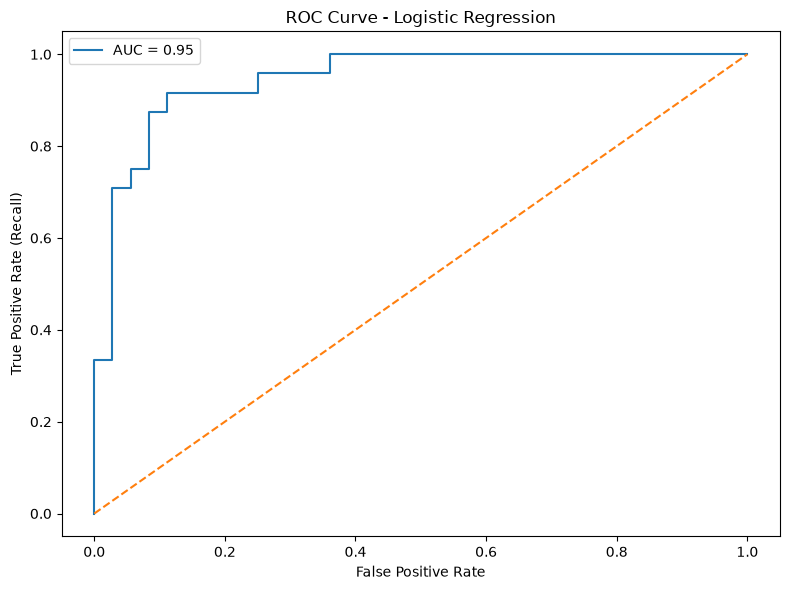

In [86]:
import matplotlib.pyplot as plt
#Creates a figure that is 8 inches wide and 6 inches high
plt.figure(figsize=(8,6))
#X-axis → False Positive Rate, Y-axis → True Positive Rate (Recall)
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
#This dashed diagonal line represents a random classifier.
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Logistic Regression")

plt.legend()
plt.tight_layout()

plt.savefig(
    "../images/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)



plt.show()

### Interpretation

The Logistic Regression model achieved an AUC of **0.95**, indicating excellent discrimination between patients with and without heart disease.

The ROC curve lies well above the diagonal reference line, demonstrating that the classifier maintains a high true positive rate while keeping the false positive rate relatively low.

These results suggest that Logistic Regression is highly effective for predicting heart disease within this dataset.

# Decision Tree

## Why Decision Trees?

Decision Trees are non-linear machine learning models that classify observations by recursively splitting the data into increasingly homogeneous groups.

Unlike Logistic Regression, Decision Trees can capture complex relationships between clinical variables without assuming a linear relationship between the predictors and the target variable.

In this project, a Decision Tree is trained and evaluated to compare its performance with Logistic Regression.

In [87]:
from sklearn.tree import DecisionTreeClassifier

In [88]:
#Uses the Gini impurity criterion to measure the quality of a split. The random_state parameter ensures reproducibility of results.
tree = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

## Model Training

The Decision Tree model is trained using the processed training dataset. During training, the algorithm learns a sequence of decision rules that best separate patients with and without heart disease.

In [89]:
#similar to the logistic regression model, we fit the decision tree model to the training data
tree.fit(X_train_processed, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

## Model Prediction

The trained Decision Tree predicts the heart disease status of patients in the testing dataset. These predictions are then compared with the true labels to evaluate model performance.

In [90]:
y_pred_tree = tree.predict(X_test_processed) #gives individual predictions (one prediction per patient).

## Model Evaluation

The confusion matrix summarizes the classification results and provides the numbers of true positives, true negatives, false positives, and false negatives.

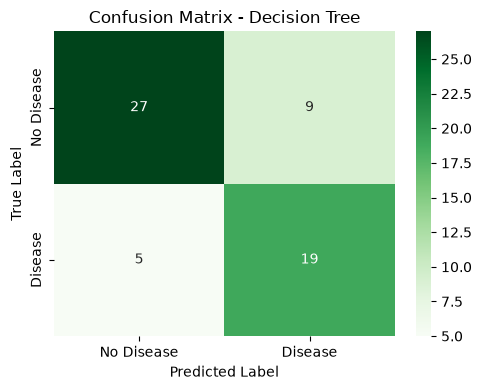

In [91]:
#confusion_matrix() summarizes all predictions together into TP, TN, FP, and FN
cm_tree = confusion_matrix(y_test, y_pred_tree)

cm_tree
plt.figure(figsize=(5,4))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Disease","Disease"],
    yticklabels=["No Disease","Disease"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Decision Tree")

plt.tight_layout()
plt.tight_layout()

plt.savefig(
    "../images/decision_tree_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [92]:
print("Accuracy :", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall   :", recall_score(y_test, y_pred_tree))
print("F1-score :", f1_score(y_test, y_pred_tree))

Accuracy : 0.7666666666666667
Precision: 0.6785714285714286
Recall   : 0.7916666666666666
F1-score : 0.7307692307692307


### Interpretation

The Decision Tree correctly classified many patients; however, its performance was lower than Logistic Regression. The model produced more false positives and false negatives, leading to lower precision, recall, and overall predictive accuracy.

## Assessing Model Generalization

A common way to determine whether a Decision Tree is overfitting is to compare its performance on the training and testing datasets.

If the training accuracy is substantially higher than the testing accuracy, the model has likely memorized the training data rather than learning patterns that generalize to unseen patients.

In [93]:
print("Training Accuracy:", tree.score(X_train_processed, y_train))
print("Testing Accuracy :", tree.score(X_test_processed, y_test))

Training Accuracy: 1.0
Testing Accuracy : 0.7666666666666667


### Interpretation

The Decision Tree achieved perfect performance on the training dataset but substantially lower performance on the testing dataset.

This large difference between training and testing accuracy indicates **overfitting**. The model has learned the training data extremely well but does not generalize effectively to unseen patients.

To improve generalization, the complexity of the Decision Tree will be reduced by limiting its maximum depth.

## Reducing Overfitting

One of the simplest ways to reduce overfitting in a Decision Tree is to limit its maximum depth.

Restricting tree depth prevents the model from creating excessively specific decision rules, allowing it to generalize better to new patient data.

In [94]:
tree_depth2 = DecisionTreeClassifier(
    max_depth=2,
    random_state=42
)

tree_depth2.fit(X_train_processed, y_train)

y_pred_depth2 = tree_depth2.predict(X_test_processed)

print("Training Accuracy:",
      tree_depth2.score(X_train_processed, y_train))

print("Testing Accuracy:",
      tree_depth2.score(X_test_processed, y_test))

Training Accuracy: 0.7763713080168776
Testing Accuracy: 0.8666666666666667


### Interpretation

Reducing the maximum tree depth decreased the complexity of the model.

Although the training accuracy decreased slightly, the testing accuracy improved, indicating that the model generalized better to unseen data and was less affected by overfitting.

## Selecting the Optimal Tree Depth

Rather than choosing the tree depth arbitrarily, multiple values of `max_depth` are evaluated.

The objective is to identify the depth that provides the best balance between model complexity and predictive performance.

In [95]:
#using a for loop to train decision tree models with different depths and store their training and testing accuracies
depths = range(1, 11)

train_scores = []
test_scores = []

for depth in depths:

    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    tree.fit(X_train_processed, y_train)

    train_scores.append(
        tree.score(X_train_processed, y_train)
    )

    test_scores.append(
        tree.score(X_test_processed, y_test)
    )

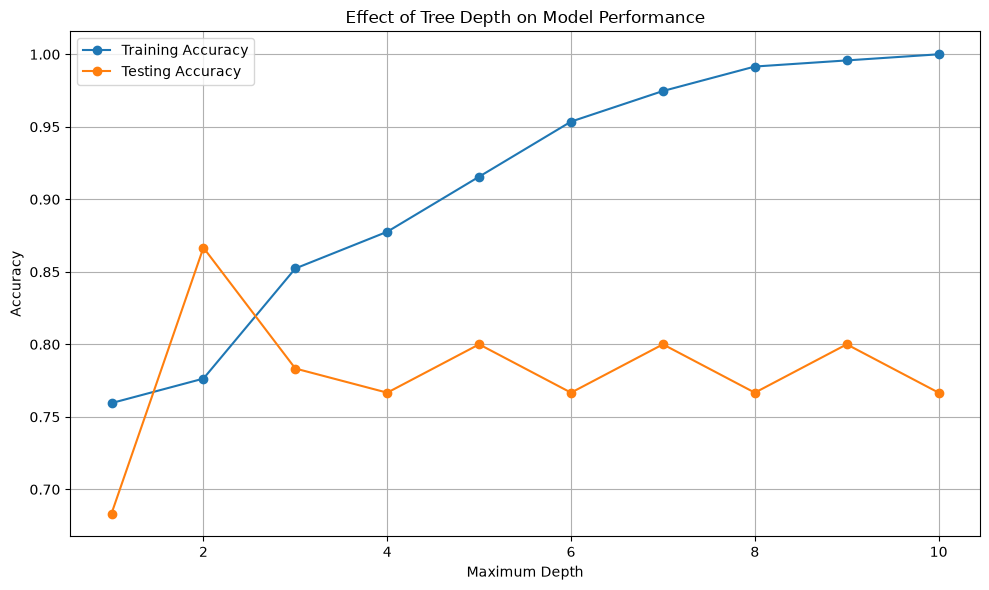

In [96]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(depths, train_scores, marker="o", label="Training Accuracy")
plt.plot(depths, test_scores, marker="o", label="Testing Accuracy")

plt.xlabel("Maximum Depth")
plt.ylabel("Accuracy")
plt.title("Effect of Tree Depth on Model Performance")

plt.legend()

plt.grid(True)
plt.tight_layout()

plt.savefig(
    "../images/tree_depth_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The training accuracy increases steadily as tree depth increases because the model becomes more flexible and better fits the training data.

However, the testing accuracy reaches its maximum at a relatively shallow depth before beginning to decline.

This behaviour demonstrates the classic trade-off between underfitting and overfitting. A tree with moderate depth provides the best balance between learning the data and generalizing to unseen patients.

# Cross-Validation

Performance estimates based on a single train-test split can vary depending on how the data are divided.

Cross-validation provides a more reliable estimate of model performance by repeatedly training and evaluating the model on different subsets of the dataset.

In [97]:
#performing cross validation
from sklearn.model_selection import cross_val_score

tree = DecisionTreeClassifier(
    max_depth=2, #using the best depth that we found
    random_state=42
)

## Performing 5-Fold Cross-Validation

The Decision Tree is evaluated using 5-fold cross-validation.

The dataset is divided into five equal parts. During each iteration, four folds are used for training while the remaining fold is used for validation.

The final performance is calculated as the average across all five folds.

In [98]:
scores = cross_val_score(
    estimator=tree, #uses this decision tree model
    X=X_train_processed, #using the training set
    y=y_train, #results 
    cv=5, #5 folds of cross validation
    scoring="accuracy" #tells sklearn which metric to evaluate
)

In [99]:
print(scores)
print("Mean Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

[0.64583333 0.77083333 0.70212766 0.61702128 0.74468085]
Mean Accuracy: 0.6960992907801419
Standard Deviation: 0.05789936986125553


### Interpretation

The cross-validation results provide a more robust estimate of the model's predictive performance.

The mean accuracy represents the expected performance on unseen data, while the standard deviation indicates the consistency of the model across different training and validation splits.

The relatively small variation between folds suggests that the Decision Tree produces reasonably stable predictions.

# Hyperparameter Tuning using GridSearchCV

Hyperparameter tuning aims to identify the combination of model parameters that produces the highest predictive performance.

GridSearchCV systematically evaluates multiple combinations of hyperparameters using cross-validation and selects the best-performing model.

## Defining the Hyperparameter Search Space

Two Decision Tree hyperparameters are evaluated:

- **criterion**: the measure used to determine the best split (Gini impurity or Entropy).
- **max_depth**: the maximum allowed depth of the Decision Tree.

Multiple combinations of these parameters are tested to identify the optimal model configuration.

In [ ]:
from sklearn.model_selection import GridSearchCV
tree = DecisionTreeClassifier(
    random_state=42
)
#It creates a dictionary that contains all the hyperparameters we want to test.
param_grid = {
    "max_depth": [1, 2, 3, 4, 5, 6],
    "criterion": ["gini", "entropy"]
}

grid_search = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1 #Instead of training models one after another, it trains multiple models in parallel (when possible), making GridSearchCV much faster. Use all workers avaialable
)

grid_search.fit(
    X_train_processed,
    y_train
)
print(grid_search.best_params_) #view best parameters
print(grid_search.best_score_)#view best score
best_tree = grid_search.best_estimator_ #get the best model
print(best_tree)
y_pred = best_tree.predict(X_test_processed)

### Interpretation

GridSearchCV identified the optimal Decision Tree configuration based on cross-validation performance.

The selected model represents the combination of hyperparameters that achieved the highest mean validation accuracy and is expected to generalize better than the default Decision Tree.

# Random Forest

## Why Random Forest?

Random Forest is an ensemble learning algorithm that combines the predictions of multiple Decision Trees using majority voting.

Unlike a single Decision Tree, Random Forest introduces randomness through bootstrap sampling and random feature selection, making the model more robust and less prone to overfitting.

In this project, Random Forest is evaluated to determine whether an ensemble approach improves predictive performance compared with Logistic Regression and a single Decision Tree.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

## Model Initialization

A Random Forest classifier consisting of 100 Decision Trees is created.

The parameter `random_state=42` ensures that the experiment is reproducible by generating the same random samples each time the notebook is executed.

In [ ]:
#creating the model
rf = RandomForestClassifier(
     n_estimators=100,
     random_state=42
)


## Model Training

The Random Forest model is trained using the processed training dataset.

During training, each Decision Tree learns from a different bootstrap sample of the training data, while considering a random subset of features at every split.

The final prediction is obtained through majority voting across all trees.

In [ ]:
rf.fit(
    X_train_processed,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [ ]:
print("Training Accuracy:", rf.score(X_train_processed, y_train))
print("Testing Accuracy:", rf.score(X_test_processed, y_test))

Training Accuracy: 1.0
Testing Accuracy: 0.8666666666666667


## Model Prediction

After training, the Random Forest model predicts the heart disease status of patients in the independent testing dataset.

These predictions are compared with the true labels to evaluate the model's performance.

## Confusion Matrix

The confusion matrix summarizes the classification performance of the Random Forest by comparing the predicted and actual disease status of each patient.

This allows us to identify the numbers of true positives, true negatives, false positives, and false negatives.

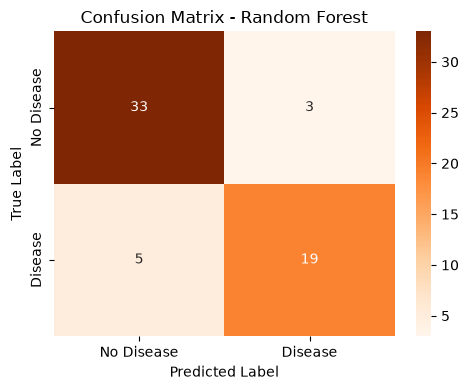

In [ ]:
y_pred_rf = rf.predict(X_test_processed)

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest")

plt.tight_layout()
plt.tight_layout()

plt.savefig(
    "../images/random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()



### Interpretation

The Random Forest correctly classified the majority of patients in both classes.

Compared with the Decision Tree, the ensemble model produced fewer classification errors, demonstrating the advantage of combining multiple Decision Trees.

However, Logistic Regression still achieved slightly higher overall predictive performance on this dataset.

## Model Evaluation

The Random Forest model is evaluated using Accuracy, Precision, Recall, and F1-score.

These complementary metrics provide a comprehensive assessment of classification performance and facilitate comparison with the other machine learning models.

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1-score :", f1_score(y_test, y_pred_rf))

Accuracy : 0.8666666666666667
Precision: 0.8636363636363636
Recall   : 0.7916666666666666
F1-score : 0.8260869565217391


### Interpretation

The Random Forest achieved strong predictive performance, with an accuracy of approximately **86.7%**.

Although the ensemble model outperformed the single Decision Tree, it did not surpass the Logistic Regression model in terms of accuracy, recall, or F1-score.

These findings suggest that increasing model complexity did not improve predictive performance for this dataset.

# Feature Importance

One advantage of Random Forest is its ability to estimate the relative importance of each predictor variable.

Feature importance scores quantify the contribution of each clinical feature to the overall predictive performance of the model.

These scores improve the interpretability of the model by identifying the variables that most strongly influence the prediction of heart disease.

In [ ]:
#feature importance
feature_importance = pd.DataFrame({
    "Feature": X_train_processed.columns,
    "Importance": rf.feature_importances_
})

## Ranking the Features

The features are sorted in descending order according to their importance scores, allowing the most influential clinical variables to be identified more easily.

In [ ]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

## Visualizing Feature Importance

A horizontal bar chart is used to visualize the relative importance of each clinical feature.

Displaying the most important variables at the top improves readability and facilitates interpretation.

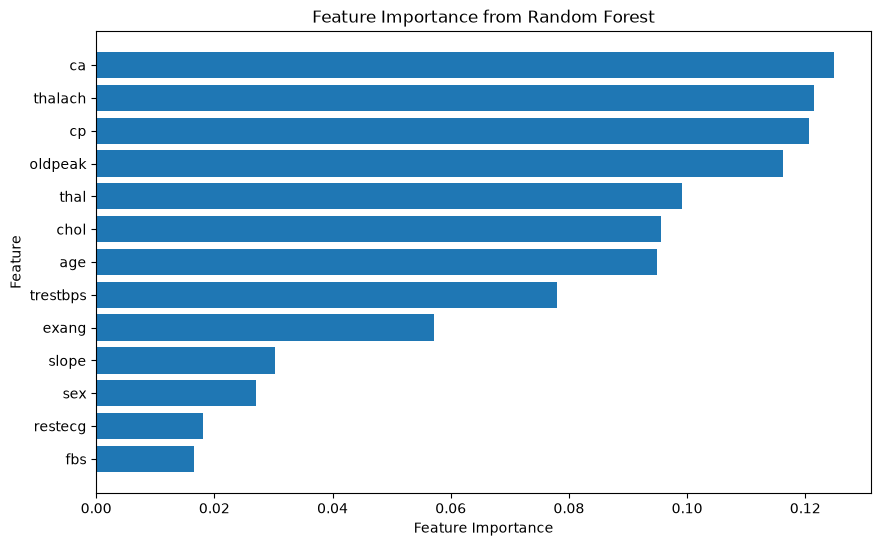

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
#horizontal bar chart as feature names can be long
plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.title("Feature Importance from Random Forest")

plt.gca().invert_yaxis() #without this top line appears from the bottom
plt.tight_layout()

plt.savefig(
    "../images/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The Random Forest identified **ca**, **thalach**, **chest pain type (cp)**, **oldpeak**, and **thal** as the most influential predictors of heart disease.

These findings are clinically plausible because these variables are well-established indicators of cardiovascular disease and are routinely used during cardiac assessment.

Conversely, variables such as **restecg**, **fasting blood sugar (fbs)**, and **sex** contributed relatively little to the model's predictions within this dataset.

# Summary of Machine Learning Models

Three machine learning algorithms were developed and evaluated for heart disease prediction.

- Logistic Regression achieved the highest overall predictive performance.
- Decision Tree demonstrated evidence of overfitting despite reasonable classification accuracy.
- Random Forest reduced overfitting and improved robustness compared with a single Decision Tree but did not outperform Logistic Regression.

Based on the evaluation metrics and the importance of minimizing false negatives in a clinical setting, Logistic Regression was selected as the final model for this study.

# Discussion

This study developed and compared three supervised machine learning algorithms—Logistic Regression, Decision Tree, and Random Forest—for predicting the presence of heart disease using routinely collected clinical variables.

Among the evaluated models, Logistic Regression achieved the best overall performance, obtaining an accuracy of **90%**, a precision of **87.5%**, a recall of **87.5%**, and an F1-score of **87.5%**. These results indicate that the model was able to correctly classify the majority of patients while maintaining a good balance between identifying patients with heart disease and minimizing false alarms.

Although Random Forest demonstrated strong predictive performance and reduced the overfitting observed in the Decision Tree, it did not outperform Logistic Regression on this dataset. This suggests that the relationships within the dataset are sufficiently captured by a simpler linear model, and that increasing model complexity does not necessarily improve predictive performance.

Feature importance analysis identified **ca**, **thalach**, **chest pain type (cp)**, **oldpeak**, and **thal** as the most influential predictors of heart disease. These findings are clinically plausible, as these variables are commonly associated with cardiovascular risk assessment and diagnosis.

From a clinical perspective, achieving a high recall is particularly important because failing to identify patients with heart disease may delay diagnosis and treatment. Therefore, the Logistic Regression model represents an appropriate balance between predictive performance, interpretability, and clinical applicability.

# Limitations

Although the developed models demonstrated strong predictive performance, several limitations should be considered.

- The dataset is relatively small, limiting the complexity of machine learning models that can be reliably trained.
- The dataset represents a specific patient population and may not generalize to all demographic or clinical settings.
- Only structured clinical variables were included. Additional information such as laboratory results, medical history, imaging data, electrocardiograms (ECGs), or genetic information could potentially improve predictive performance.
- Hyperparameter tuning was limited to a small set of Decision Tree parameters. More extensive optimization may further improve model performance.
- External validation using an independent dataset was not performed, and therefore the generalizability of the models cannot be fully assessed.

# Conclusion

This project demonstrated the complete machine learning workflow for predicting heart disease using clinical patient data.

Following data preprocessing, exploratory data analysis, model development, hyperparameter tuning, cross-validation, and model evaluation, Logistic Regression was identified as the best-performing algorithm for this dataset.

The model achieved an accuracy of **90%** while maintaining high precision, recall, and F1-score. These results indicate that Logistic Regression provides a reliable and interpretable approach for heart disease prediction using routinely collected clinical information.

Overall, this study highlights the importance of comparing multiple machine learning models rather than assuming that more complex algorithms will always provide better performance. Careful evaluation demonstrated that the simplest model achieved the strongest balance between predictive accuracy, generalization, and interpretability.

# Future Work

Several opportunities exist to further improve this work.

- Evaluate additional machine learning algorithms such as Support Vector Machines (SVM), XGBoost, and LightGBM.
- Apply deep learning approaches to larger cardiovascular datasets.
- Incorporate additional clinical modalities, including ECG signals, cardiac imaging, laboratory biomarkers, and genomic information.
- Perform external validation using independent hospital datasets to evaluate model generalizability.
- Develop an interactive web application that allows clinicians to estimate heart disease risk using patient information.
- Investigate explainable artificial intelligence (XAI) techniques such as SHAP and LIME to improve model transparency and support clinical decision-making.

# Key Takeaways

Throughout this project, the complete supervised machine learning pipeline was implemented, including:

- Clinical problem formulation
- Exploratory Data Analysis (EDA)
- Data preprocessing
- Feature scaling
- Logistic Regression
- Decision Tree
- Random Forest
- Hyperparameter tuning using GridSearchCV
- Cross-validation
- Model evaluation
- ROC curve analysis
- Feature importance analysis
- Model comparison

This project demonstrates not only the implementation of machine learning algorithms but also the ability to critically evaluate model performance, interpret results, and communicate findings in a structured and reproducible manner.